In [1]:
import galstreams
mws = galstreams.MWStreams(verbose=False)

import sys, pickle, os
from importlib import reload
from tqdm import tqdm, trange

import numpy as np, pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import agama 
Gyr_to_AgamaTime = 1.0227 # 1 Gyr in Agama time units (kpc/(km/s))
import nbody_streams.agama_helper as ah

import emcee
import corner

from astropy import units as u
import astropy.coordinates as coord
from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
from astropy import table

Initializing galstreams library from master_log... 


In [2]:
sys.path.append('../scripts/')
from coordinate_utils import get_rotation_matrix, sf_to_icrs, icrs_to_sf
from generate_sim_stream import create_stream_particle_spray
from stream_likelihood import log_likelihood, make_spline, log_prior, log_probability
from stream_data_utils import read_in_data

In [3]:
aau_member_path = '../data/aau_members.csv'
aau_distance_path = '../data/aau_bhb_rrl.csv'

aau_table = pd.read_csv(aau_member_path)
aau_bhb_rrl_data = pd.read_csv(aau_distance_path)

aau_bhb_rrl_data.columns = aau_bhb_rrl_data.columns.str.lower()

df_aau, prog_pars_aau, prog_pars_icrs_aau, df_distance_aau = read_in_data(aau_table, 'distance_modulus', aau_bhb_rrl_data)

prog_pars_aau[2] = 10**(((prog_pars_aau[2]) + 5) / 5) / 1000.0
prog_pars_icrs_aau[2] = 10**(((prog_pars_icrs_aau[2]) + 5) / 5) / 1000.0 

jet_member_path = '../data/jet_members.csv'

jet_table = pd.read_csv(jet_member_path)

df_jet, distance_fit_jet, prog_pars_jet, prog_pars_icrs_jet = read_in_data(jet_table, 'bhb_dist')

In [4]:
#linear_fit = lambda t: -0.0356 * t + 1.0339

In [5]:
#Constructing a data dictionary given stream data_frame
data_dict_aau = dict(
    phi1_obs = df_aau['phi1'].values,
    phi1_obs_dist = df_distance_aau['phi1'].values,
    phi2_obs = df_aau['phi2'].values,
    rv_obs = df_aau['vel_calib'].values,
    rv_obs_errors = df_aau['vel_calib_std'].values,
    dist_obs = 10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0,
    dist_obs_errors = ((10**(((df_distance_aau['distance_modulus'].values) + 5) / 5) / 1000.0)*0.1),
    pmra_cosdec_obs = df_aau['pmra'].values,
    pmra_cosdec_obs_errors = df_aau['pmra_error'].values,
    pmdec_obs = df_aau['pmdec'].values,
    pmdec_obs_errors = df_aau['pmdec_error'].values,
)

data_dict_jet = dict(
    phi1_obs = df_jet['phi1'].values,
    phi2_obs = df_jet['phi2'].values,
    rv_obs = df_jet['vel_calib'].values,
    rv_obs_errors = df_jet['vel_calib_std'].values,
    dist_obs = df_jet['bhb_dist'].values,
    dist_obs_errors = (df_jet['bhb_dist'].values*0.1),
    pmra_cosdec_obs = df_jet['pmra'].values,
    pmra_cosdec_obs_errors = df_jet['pmra_error'].values,
    pmdec_obs = df_jet['pmdec'].values,
    pmdec_obs_errors = df_jet['pmdec_error'].values,
)

In [6]:
# BASE_POT_PATH = '../'
# potMW_path = os.path.join(BASE_POT_PATH, 'MWPotential22.ini')
# ## potential models to load
# potMW = agama.Potential(file=potMW_path)
# potTotal= agama.Potential(potMW)

In [21]:
# # parent directory
sim_dir = f'/astro/store/shire/stream_team/potential_models/MW_LMC/suite_223/'

def get_orbit_vectors(data):
    return {
        'times': data[:, 1],
        'mw': data[:, 6:12],
        'lmc': data[:, 12:18]
    }

# # 
lmax = 6
h5_MW_sph = f'{sim_dir}/MW.none_{lmax}.coef_mult.h5'
h5_MW_azi = f'{sim_dir}/MW.none_{lmax}.coef_cylsp.h5'
h5_LMC_sph = f'{sim_dir}/LMC.none_{lmax}.coef_mult.h5'

snap_orbits = np.loadtxt(sim_dir+'suite_223_orbit.txt')
orbits = get_orbit_vectors(snap_orbits)
time_in_Agama = orbits['times']*Gyr_to_AgamaTime # # converted to Agama times for faster lookup!
# the times are described from 0 to 2 ~ Gyr, the final step being the current MW-LMC locations. 

# # # Build the Uniform background force:
# LMC_posvel_in_MWframe = orbits['lmc'] - orbits['mw']
# LMC_traj = np.column_stack([time_in_Agama, LMC_posvel_in_MWframe])

trajMWx = agama.Spline(time_in_Agama, orbits['mw'][:, 0], der=orbits['mw'][:, 3])
trajMWy = agama.Spline(time_in_Agama, orbits['mw'][:, 1], der=orbits['mw'][:, 4])
trajMWz = agama.Spline(time_in_Agama, orbits['mw'][:, 2], der=orbits['mw'][:, 5])

In [23]:
# MW centre acceleration is minus the second derivative of its trajectory in the inertial frame
negative_accMW   = np.column_stack([time_in_Agama, -trajMWx(time_in_Agama, 2), -trajMWy(time_in_Agama, 2), -trajMWz(time_in_Agama, 2)])
potacc  = agama.Potential(type='UniformAcceleration', file=negative_accMW) # this is the MW-non interial correction acceleration

In [24]:
# # load the entire time-evolving potential
potMW_mult = ah.load_agama_evolving_potential(h5_MW_sph)
potMW_cylsp = ah.load_agama_evolving_potential(h5_MW_azi)
# potLMC_mult = ah.load_agama_evolving_potential(h5_LMC_sph, center=LMC_traj)
potTot_evolv =  potMW_mult + potMW_cylsp  + potacc

In [25]:
jet_ic = np.array([ -17.64995315,  -26.91475835,    9.48757263,   -2.08191693,
        -91.78693674, -100.95214308])

jet_rot_mat = get_rotation_matrix('Jet-F22', mws)

print(jet_rot_mat)
print(snap_orbits[:, 1].min(), snap_orbits[:, 1].max())

[[-0.69533693  0.61240175 -0.37612584]
 [-0.62909984 -0.26561497  0.73053548]
 [ 0.34747655  0.744589    0.56995374]]
0.0 2.0


In [26]:
# # stream progenitor profile parameters
prog_mass, prog_scaleradius =  20_000, 10/1_000 # Msun, kpc
Age_stream_inGyr = 5.0 # Gyr --<

# # num_particles for the spray model: 
num_particles = 2_000 # # preferably a multiple of 2, leading+trailing arm

#generate the stream with best_fit_params
gen_best_stream = create_stream_particle_spray(
    pot_host=potTot_evolv, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=jet_ic, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

best_stream_model = gen_best_stream['part_xv']

galcen_best_stream = coord.Galactocentric(
        x=best_stream_model[:,0] * u.kpc,
        y=best_stream_model[:,1] * u.kpc,
        z=best_stream_model[:,2] * u.kpc,
        v_x=best_stream_model[:,3] * u.km/u.s,
        v_y=best_stream_model[:,4] * u.km/u.s,
        v_z=best_stream_model[:,5] * u.km/u.s,
        representation_type='cartesian',
        differential_type='cartesian'
    )

icrs_best_stream = galcen_best_stream.transform_to(coord.ICRS())

ra_max = icrs_best_stream.ra.value
dec_max = icrs_best_stream.dec.value
dist_max = icrs_best_stream.distance.value
pmra_max = icrs_best_stream.pm_ra_cosdec.value
pmdec_max = icrs_best_stream.pm_dec.value
rv_max = icrs_best_stream.radial_velocity.value

phi1_max, phi2_max = icrs_to_sf(ra_max, dec_max, jet_rot_mat)

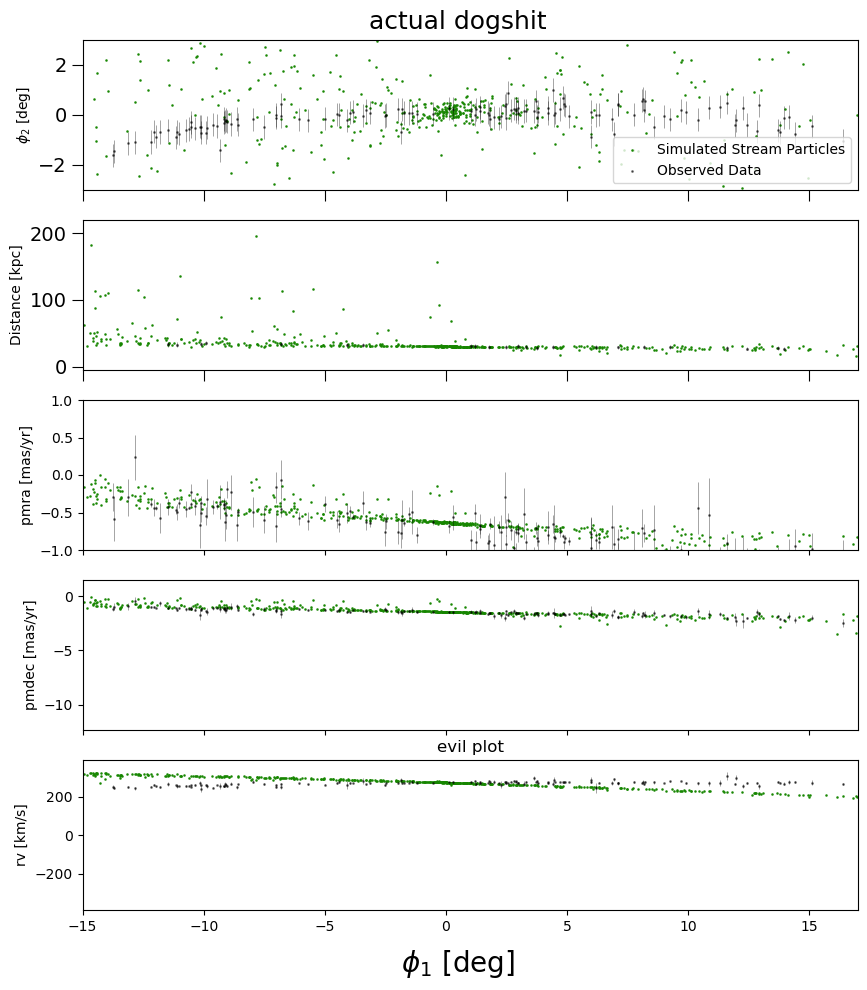

In [30]:
fig, ax = plt.subplots(5,1, sharex = True)
#plot with best-fit progenitor IC's from MCMC!
fig.suptitle(t ="actual dogshit",ha= 'center', fontsize = 18 )
fig.set_size_inches(10,10)
plt.subplots_adjust(top=0.95, bottom = 0.08)
fig.set_size_inches(10,10)
fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
ax[-1].set_xlim(-15,17)
ax[-1].set_title(label ='evil plot',loc='center' )
#simulation
ax[0].scatter(phi1_max, phi2_max,s=0.75,color='#168600', alpha= 0.9, label = 'Simulated Stream Particles')
ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[0].tick_params(axis='both', which='minor', length=3)
ax[0].set_ylim(-3,3)
ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)

ax[1].scatter(phi1_max, dist_max,s=0.75,color='#168600',alpha= 0.9 )
ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
ax[1].tick_params(axis='both', which='minor', length=3)
ax[1].set_ylabel('Distance [kpc]', fontsize=10)
#ax[1].set_ylim(24,37)

ax[2].scatter(phi1_max, pmra_max,s=0.75,color='#168600',alpha= 0.9 )
ax[2].set_ylim(-1,1)
ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
#ax[2].set_ylim(-2,0.5)

ax[3].scatter(phi1_max, pmdec_max,s=0.75,color='#168600',alpha= 0.9 )
ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
#ax[3].set_ylim(-3,-0.25)

ax[4].scatter(phi1_max, rv_max,s=0.75,color='#168600',alpha= 0.9)
ax[4].set_ylabel('rv [km/s]', fontsize=10)
#ax[4].set_ylim(200,350)

#data
ax[0].scatter(df_jet['phi1'], df_jet['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
ax[0].errorbar(df_jet['phi1'], df_jet['phi2'], yerr=np.nanstd(df_jet['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[1].scatter(df_jet['phi1'], df_jet['bhb_dist'],s=1.5,color='k', alpha = 0.5)
ax[1].errorbar(df_jet['phi1'],df_jet['bhb_dist'], yerr=((df_jet['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)


ax[2].scatter(df_jet['phi1'], df_jet['pmra'],s=1,color='k', alpha = 0.5)
ax[2].errorbar(df_jet['phi1'], df_jet['pmra'], yerr=df_jet['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)

ax[3].scatter(df_jet['phi1'], df_jet['pmdec'],s=1,color='k',alpha = 0.5)
ax[3].errorbar(df_jet['phi1'], df_jet['pmdec'], yerr=df_jet['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[4].scatter(df_jet['phi1'], df_jet['vel_calib'],s=1,color='k', alpha = 0.5)
ax[4].errorbar(df_jet['phi1'], df_jet['vel_calib'], yerr=df_jet['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)

ax[0].legend(loc = 'lower right')

In [34]:
loop_stream_age = 0.0

for i in np.arange(0.1, 2.0, 0.1):
    loop_stream_age = i
    gen_best_stream = create_stream_particle_spray(
    pot_host=potTot_evolv, 
    initmass=prog_mass, 
    scaleradius=prog_scaleradius, 
    prog_pot_kind='Plummer', 
    sat_cen_present=jet_ic, 
    num_particles=num_particles,
    time_end=0.0, 
    time_total=Age_stream_inGyr, save_rate=1,
    #add_perturber={'mass':0},
)

    best_stream_model = gen_best_stream['part_xv']
    
    galcen_best_stream = coord.Galactocentric(
            x=best_stream_model[:,0] * u.kpc,
            y=best_stream_model[:,1] * u.kpc,
            z=best_stream_model[:,2] * u.kpc,
            v_x=best_stream_model[:,3] * u.km/u.s,
            v_y=best_stream_model[:,4] * u.km/u.s,
            v_z=best_stream_model[:,5] * u.km/u.s,
            representation_type='cartesian',
            differential_type='cartesian'
        )
    
    icrs_best_stream = galcen_best_stream.transform_to(coord.ICRS())
    
    ra_max = icrs_best_stream.ra.value
    dec_max = icrs_best_stream.dec.value
    dist_max = icrs_best_stream.distance.value
    pmra_max = icrs_best_stream.pm_ra_cosdec.value
    pmdec_max = icrs_best_stream.pm_dec.value
    rv_max = icrs_best_stream.radial_velocity.value
    
    phi1_max, phi2_max = icrs_to_sf(ra_max, dec_max, jet_rot_mat)
    
    fig, ax = plt.subplots(5,1, sharex = True)
    #plot with best-fit progenitor IC's from MCMC!
    fig.suptitle(t ="actual dogshit",ha= 'center', fontsize = 18 )
    fig.set_size_inches(10,10)
    plt.subplots_adjust(top=0.95, bottom = 0.08)
    fig.set_size_inches(10,10)
    fig.supxlabel(r'$\phi_1$ [deg]',fontsize=20)
    ax[-1].set_xlim(-15,17)
    ax[-1].set_title(label ='evil plot',loc='center' )
    #simulation
    ax[0].scatter(phi1_max, phi2_max,s=0.75,color='#168600', alpha= 0.9, label = 'Simulated Stream Particles')
    ax[0].tick_params(axis='both', which='major', labelsize=14., length=8)
    ax[0].tick_params(axis='both', which='minor', length=3)
    ax[0].set_ylim(-3,3)
    ax[0].set_ylabel(r'$\phi_2$ [deg]', fontsize=10)
    
    ax[1].scatter(phi1_max, dist_max,s=0.75,color='#168600',alpha= 0.9 )
    ax[1].tick_params(axis='both', which='major', labelsize=14., length=8)
    ax[1].tick_params(axis='both', which='minor', length=3)
    ax[1].set_ylabel('Distance [kpc]', fontsize=10)
    #ax[1].set_ylim(24,37)
    
    ax[2].scatter(phi1_max, pmra_max,s=0.75,color='#168600',alpha= 0.9 )
    ax[2].set_ylim(-1,1)
    ax[2].set_ylabel('pmra [mas/yr]', fontsize=10)
    #ax[2].set_ylim(-2,0.5)
    
    ax[3].scatter(phi1_max, pmdec_max,s=0.75,color='#168600',alpha= 0.9 )
    ax[3].set_ylabel('pmdec [mas/yr]', fontsize=10)
    #ax[3].set_ylim(-3,-0.25)
    
    ax[4].scatter(phi1_max, rv_max,s=0.75,color='#168600',alpha= 0.9)
    ax[4].set_ylabel('rv [km/s]', fontsize=10)
    #ax[4].set_ylim(200,350)
    
    #data
    ax[0].scatter(df_jet['phi1'], df_jet['phi2'] , s=1,color='k', alpha = 0.5, label = 'Observed Data')
    ax[0].errorbar(df_jet['phi1'], df_jet['phi2'], yerr=np.nanstd(df_jet['phi2']), fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[1].scatter(df_jet['phi1'], df_jet['bhb_dist'],s=1.5,color='k', alpha = 0.5)
    ax[1].errorbar(df_jet['phi1'],df_jet['bhb_dist'], yerr=((df_jet['bhb_dist'].values)*0.1), fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)
    
    
    ax[2].scatter(df_jet['phi1'], df_jet['pmra'],s=1,color='k', alpha = 0.5)
    ax[2].errorbar(df_jet['phi1'], df_jet['pmra'], yerr=df_jet['pmra_error'], fmt='none', ecolor='k',alpha = 0.5,capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[3].scatter(df_jet['phi1'], df_jet['pmdec'],s=1,color='k',alpha = 0.5)
    ax[3].errorbar(df_jet['phi1'], df_jet['pmdec'], yerr=df_jet['pmdec_error'], fmt='none', ecolor='k', alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[4].scatter(df_jet['phi1'], df_jet['vel_calib'],s=1,color='k', alpha = 0.5)
    ax[4].errorbar(df_jet['phi1'], df_jet['vel_calib'], yerr=df_jet['vel_calib_std'], fmt='none', ecolor='k',alpha = 0.5, capsize=0, capthick=0.7, elinewidth=0.5)
    
    ax[0].legend(loc = 'lower right')
    fig.text(0.7, 0.02, f'Time: {i - 6.0:.1f} Gyr')
    plt.savefig(f'../jet_gif_time_evo_{i:.1f}.png')
    plt.close()